In [ ]:
pip install pandas

In [ ]:
import pandas as pd

# Step 1: Load the CSV file into a DataFrame
input_file = "full data.csv"  # Replace with your actual file name
output_file = "merged_full_data.csv"  # Name of the output file

# Read the CSV file
df = pd.read_csv(input_file, engine='python')

# Step 2: Merge the 'title' and 'text' columns into one column
# Use a space (' ') to separate the title and text
df['merged_text'] = df['title'].fillna('') + " " + df['text'].fillna('')

# Step 3: Drop the original 'title' and 'text' columns (optional)
# If you want to keep them, skip this step
df = df.drop(columns=['title', 'text'])

# Step 4: Save the updated DataFrame to a new CSV file
df.to_csv(output_file, index=False)

print(f"Merged data saved to {output_file}")

Merged data saved to merged_full_data.csv


In [ ]:
  import nltk
  nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources (run this only once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load your dataset
input_file = "merged_full_data.csv"  # Replace with your actual file name
df = pd.read_csv(input_file)

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Define a preprocessing function
def preprocess_text(text):
    # 1. Lowercase the text
    text = str(text).lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenize the text
    tokens = word_tokenize(text)

    # 5. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 6. Lemmatize the tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 7. Join tokens back into a single string
    cleaned_text = ' '.join(tokens)

    return cleaned_text

# Apply preprocessing to the 'merged_text' column
df['cleaned_text'] = df['merged_text'].apply(preprocess_text)

# Save the preprocessed data to a new CSV file
output_file = "preprocessed_data.csv"
df.to_csv(output_file, index=False)

print(f"Preprocessed data saved to {output_file}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
/tmp/ipython-input-1047813168.py:15: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


Preprocessed data saved to preprocessed_data.csv


In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources (run this only once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load your dataset
input_file = "preprocessed_data.csv"  # Replace with your actual file name
df = pd.read_csv(input_file)

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Define a list of domain-specific noise terms
domain_specific_noise = [
    "chatgpt", "ai", "gpt", "llm", "model", "use", "like", "im", "ive",
    "response", "prompt", "data", "language", "tool", "openai", "google",
    "human", "user", "question", "paper", "llama", "openais", "deepseek",
    "perplexity", "chrome", "app", "apps", "code"
]

# Define a list of generic terms
generic_terms = [
    "new", "using", "know", "think", "help", "really", "make", "want",
    "say", "used", "need", "time", "work", "also", "even", "still",
    "many", "much", "well", "way", "thing", "something", "anything"
]

# Combine stop words, domain-specific noise, and generic terms
combined_noise = set(stop_words).union(domain_specific_noise).union(generic_terms)

# Define a preprocessing function
def preprocess_text(text):
    # 1. Lowercase the text
    text = str(text).lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenize the text
    tokens = word_tokenize(text)

    # 5. Remove stopwords, domain-specific noise, and generic terms
    tokens = [word for word in tokens if word not in combined_noise]

    # 6. Lemmatize the tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 7. Join tokens back into a single string
    cleaned_text = ' '.join(tokens)

    return cleaned_text

# Apply preprocessing to the 'merged_text' column
df['cleaned_text'] = df['merged_text'].apply(preprocess_text)

# Save the preprocessed data to a new CSV file
output_file = "preprocessed_data.csv"
df.to_csv(output_file, index=False)

print(f"Preprocessed data saved to {output_file}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/tmp/ipython-input-549639496.py:15: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


Preprocessed data saved to preprocessed_data.csv


In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 598.5 kB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    return scores['compound']  # Compound score ranges from -1 (negative) to +1 (positive)

# Apply sentiment analysis
df['sentiment_score'] = df['cleaned_text'].apply(get_sentiment)

# Categorize sentiment into positive, negative, or neutral
def categorize_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['sentiment_score'].apply(categorize_sentiment)

# Save the results
df.to_csv("sentiment_analysis_results.csv", index=False)

print("Sentiment analysis completed.")

Sentiment analysis completed.


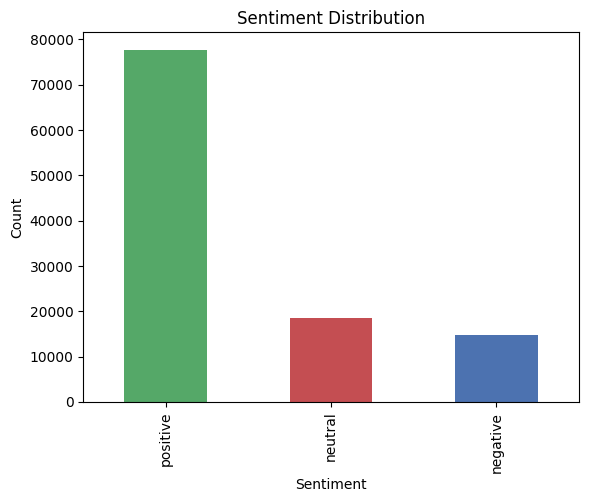

In [ ]:

import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()
sentiment_counts.plot(kind='bar', color=['#55A868', '#C44E52', '#4C72B0'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

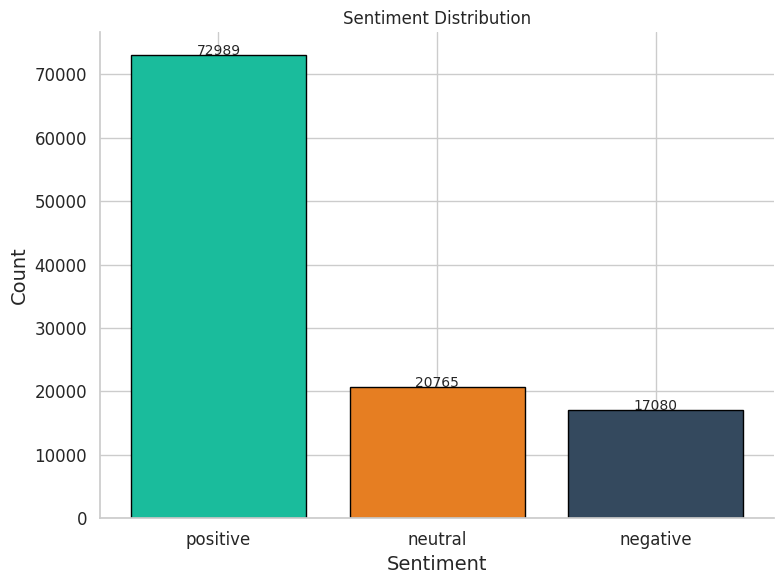

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns  # For better styling

# Set a professional style using Seaborn
sns.set(style="whitegrid")  # Adds a clean grid background
plt.figure(figsize=(8, 6))  # Adjust figure size for better proportions

# Count sentiment occurrences
sentiment_counts = df['sentiment'].value_counts()

# Define colors for each sentiment category
#colors = ['#55A868', '#A85568', '#B8B8B8']# Green, Red, Blue (customized)   '#55A868', '#C44E52', '#4C72B0'
colors = ['#1ABC9C', '#E67E22', '#34495E']
# Plot the bar chart
bar_plot = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')

# Add value labels on top of each bar
for bar in bar_plot:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}', ha='center', fontsize=10)

# Add title and axis labels
plt.title('Sentiment Distribution', fontsize=12)
plt.xlabel('Sentiment', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Customize ticks for better readability
plt.xticks(fontsize=12, rotation=0)  # No rotation needed for short labels
plt.yticks(fontsize=12)

# Remove spines for a cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add padding to prevent clipping of labels
plt.tight_layout()

# Save the figure as a high-resolution image
plt.savefig("sentiment_distribution.png", dpi=300, bbox_inches='tight')  # Save as PNG


# Show the plot (optional, if you want to preview it)
plt.show()

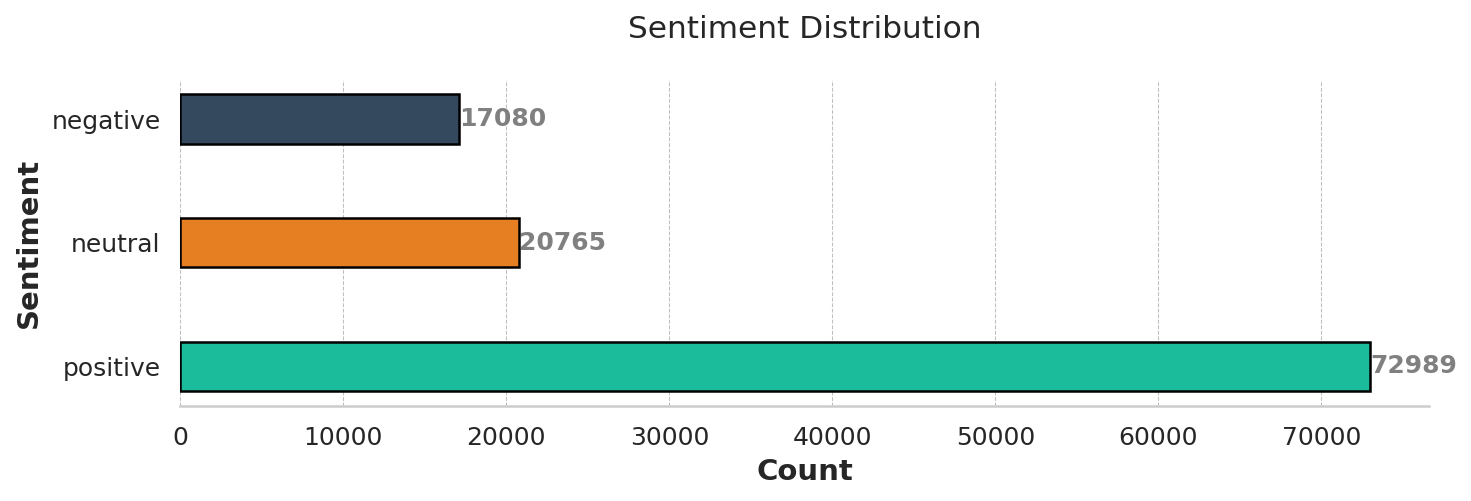

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional style
sns.set(style="whitegrid")

# Use a wider, taller figure for clarity and high-res output
plt.figure(figsize=(10, 3.5), dpi=150)  # High DPI rendering

# Count sentiment occurrences
sentiment_counts = df['sentiment'].value_counts()

# 🔥 HD / Vibrant Colors: Modern, bold, and visually balanced
#colors = ['#2C3E50', '#3498DB', '#E74C3C'] # Emerald Green, Alizarin Red, Vivid Blue
# Alternative premium palette (uncomment if preferred):
colors = ['#1ABC9C', '#E67E22', '#34495E']  # Turquoise, Pumpkin, Dark Blue-Gray

# Create horizontal bar chart with thin bars
bar_plot = plt.barh(
    sentiment_counts.index,
    sentiment_counts.values,
    color=colors,
    edgecolor='black',
    height=0.4,       # Thin bars
    linewidth=1.2     # Slightly refined edge
)

# Add value labels at the end of each bar
for bar in bar_plot:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center', ha='left',
             fontsize=12, fontweight='bold', color='gray')

# Chart title and labels
plt.title('Sentiment Distribution', fontsize=15, pad=20)
plt.xlabel('Count', fontsize=14, fontweight='semibold')
plt.ylabel('Sentiment', fontsize=14, fontweight='semibold')

# Customize tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Remove unnecessary spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)

# Optional: Add subtle grid for readability (on x-axis only)
ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.yaxis.grid(False)  # Disable y-grid

# Improve layout spacing
plt.tight_layout()

# Save as high-resolution PNG
plt.savefig("sentiment_distribution.png", dpi=300, bbox_inches='tight', format='png',
            facecolor='white', edgecolor='none')

# Show the plot
plt.show()

/tmp/ipython-input-3431750196.py:62: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(0, sentiment_counts.max() * 1.2)  # مساحة للنص
/tmp/ipython-input-3431750196.py:65: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.95])  # ترك مساحة صغيرة أعلى للعنوان


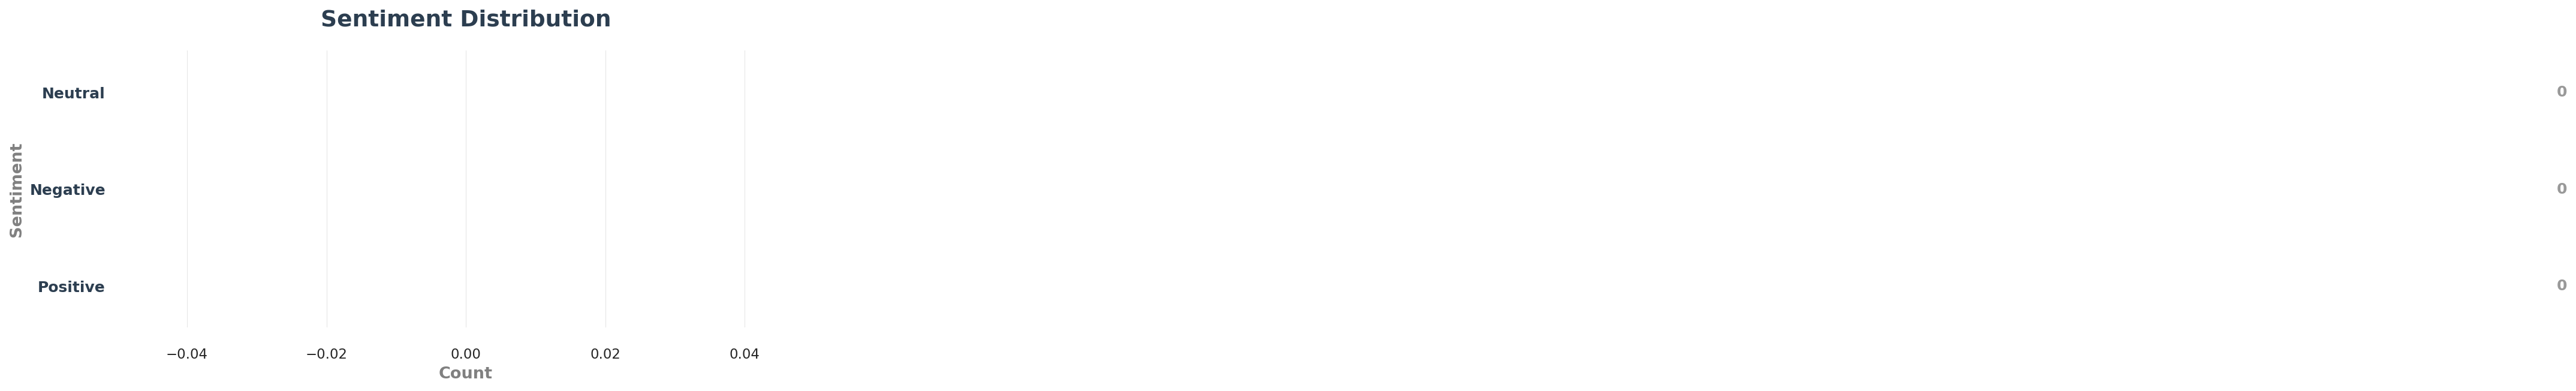

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# === الإعدادات البصرية: نظيف، بدون شريط خلفي مزعج ===
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(10, 4), dpi=150)  # أقصر ارتفاعًا لتقريب الأعمدة بصريًا

# === ترتيب الفئات (لتحكم في الترتيب)
order = ['Positive', 'Negative', 'Neutral']
sentiment_counts = df['sentiment'].value_counts().reindex(order, fill_value=0)

# === ألوان حديثة وناعمة (بدون حواف سوداء) ===
colors = ['#4CAF50', '#F44336', '#2196F3']  # Material Design: Green, Red, Blue
# أو جرب: ['#66BB6A', '#EF5350', '#42A5F5'] — نسخة فاتحة أكثر

# === رسم الأعمدة الأفقية مع تقريبها (barh) ===
# باستخدام height أكبر قليلًا + تقليل المساحة الرأسية
bar_plot = plt.barh(
    sentiment_counts.index,
    sentiment_counts.values,
    color=colors,
    height=0.6,        # سمك مناسب: يملأ الفراغ ويقرب الأعمدة
    edgecolor='none',  # ✅ لا حدود سوداء بعد الآن!
    linewidth=0
)

# === إضافة القيم على يمين العمود ===
for bar in bar_plot:
    width = bar.get_width()
    plt.text(width + 0.3,
             bar.get_y() + bar.get_height() / 2,
             f'{int(width)}',
             va='center',
             ha='left',
             fontsize=12,
             fontweight='bold',
             color='gray',
             alpha=0.8)

# === العناوين ===
plt.title('Sentiment Distribution', fontsize=18, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel('Count', fontsize=13, fontweight='semibold', color='gray')
plt.ylabel('Sentiment', fontsize=13, fontweight='semibold', color='gray')

# === تنسيق المحاور ===
plt.xticks(fontsize=11)
plt.yticks(fontsize=12, color='#2C3E50', fontweight='semibold')

# === إزالة الحدود غير الضرورية ===
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  # إزالة العمود الأيسر
ax.spines['bottom'].set_visible(False)  # سيتم الاعتماد على grid فقط

# === شبكة خفيفة على المحور X فقط ===
ax.xaxis.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.2)
ax.yaxis.grid(False)

# === تركيز على البيانات: تقليل الهوامش ===
ax.xaxis.set_tick_params(pad=10)  # تقليل المسافة بين النص والرسم
plt.xlim(0, sentiment_counts.max() * 1.2)  # مساحة للنص

# === تحسين التباعد العام ===
plt.tight_layout(rect=[0, 0, 1, 0.95])  # ترك مساحة صغيرة أعلى للعنوان

# === حفظ بصيغة عالية الجودة ===
plt.savefig("sentiment_distribution_clean.png",
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
            edgecolor='none',
            transparent=False,
            format='png')

# عرض الرسم
plt.show()

In [ ]:
#Topic modeling
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize the cleaned text
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_text'])

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# Apply LDA
lda = LatentDirichletAllocation(n_components=10, random_state=42)  # Extract 5 topics
topic_distribution = lda.fit_transform(X)

# Assign the dominant topic to each document
df['dominant_topic'] = topic_distribution.argmax(axis=1)

# Print top words for each topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_top_words(lda, vectorizer.get_feature_names_out(), 10)

Topic #0:
plan search pro year user gemini content information offer microsoft
Topic #1:
image people dont job chat llm plus better prompt question
Topic #2:
year answer software people project job feel student image day
Topic #3:
game study say create memory video survey tech save education
Topic #4:
step instruction specific custom llm model document question information text
Topic #5:
intelligence artificial podcast model chatbot safety technology company tech world
Topic #6:
apple copy learning update million deep image worker law list
Topic #7:
voice model token context text mixtral assistant output training opensource
Topic #8:
chat free conversation story chatbot prompt user best xb site
Topic #9:
robot python chat writing agent translate script good english create
